In [105]:
import pickle
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

Loading Data

In [106]:

s2_path = "datasets/WESAD/S2/S2.pkl"
# we have to change the encoding because the data appears to have been
# pickled with py2 and we are in py 3
with open(s2_path, 'rb') as file:
    s2_data = pickle.load(file, encoding='latin1')

Inspecting The Dataset

In [107]:
print(s2_data.keys())
# print(s2_data.values())
# print(s2_data.items())

dict_keys(['signal', 'label', 'subject'])


In [108]:
for key, value in s2_data.items():
    print(f"{key}: {type(value)}")

signal: <class 'dict'>
label: <class 'numpy.ndarray'>
subject: <class 'str'>


In [109]:
for key, value in s2_data['signal'].items():
    print(f"{key}: {type(value)}")

chest: <class 'dict'>
wrist: <class 'dict'>


In [110]:
for parant_key, value in s2_data['signal'].items():
    for key, value in s2_data['signal'][parant_key].items():
        print(f"{parant_key}: {key}: {type(value)}")

chest: ACC: <class 'numpy.ndarray'>
chest: ECG: <class 'numpy.ndarray'>
chest: EMG: <class 'numpy.ndarray'>
chest: EDA: <class 'numpy.ndarray'>
chest: Temp: <class 'numpy.ndarray'>
chest: Resp: <class 'numpy.ndarray'>
wrist: ACC: <class 'numpy.ndarray'>
wrist: BVP: <class 'numpy.ndarray'>
wrist: EDA: <class 'numpy.ndarray'>
wrist: TEMP: <class 'numpy.ndarray'>


In [111]:

labels = s2_data['label']

# Print unique labels
unique_labels = np.unique(labels)
print("Unique labels:", unique_labels)

Unique labels: [0 1 2 3 4 6 7]


Label Meaning in WESAD

In [ ]:
""" 
According to the wesad_readme.pdf,

Label |  Meaning
------|---------------------------------------------
0     | Not defined / transient (noise, transitions)
1     | Baseline (normal, relaxed)
2     | Stress 
3     | Amusement (positive emotion, fun)
4     | Meditation (relaxed but focused state)
5     | Ignore (invalid or experiment error)
6     | Ignore (invalid or experiment error)
7     | Ignore (invalid or experiment error)


So we should use only labels 1, 2, 3, 4

Practically:
Label 1 → Baseline (normal)
Label 2 → Stress (this is what we want to detect!)
Label 3 → Amusement (happy/positive stress)
Label 4 → Meditation (calmness)

Or we could do simple binary classification (Stress / No Stress)
label 1,3,4 -> No Stress
Labwl 2     -> Stress

"""

baseline_indices 800800
stress_indices 430500
amusement_indices 253400
meditation_indices 537599


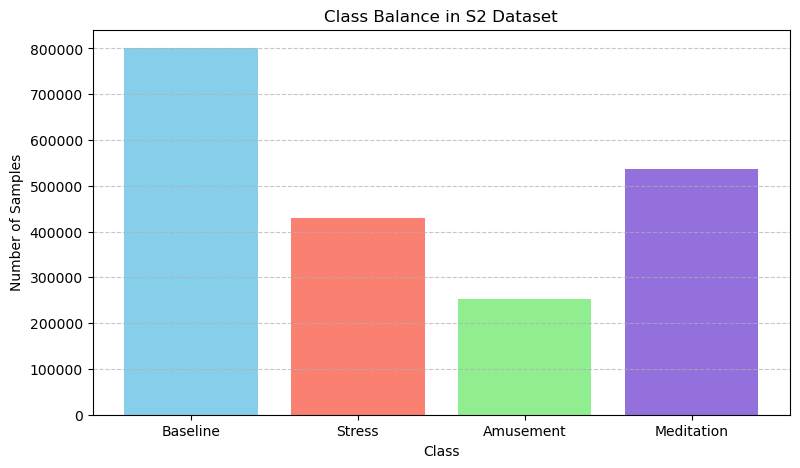

In [112]:
baseline_indices = np.nonzero(s2_data['label']==1)[0]
stress_indices = np.nonzero(s2_data['label']==2)[0]
amusement_indices = np.nonzero(s2_data['label']==3)[0]
meditation_indices = np.nonzero(s2_data['label']==4)[0]

print("baseline_indices", len(baseline_indices))
print("stress_indices", len(stress_indices))
print("amusement_indices", len(amusement_indices))
print("meditation_indices", len(meditation_indices))

# Prepare for plotting
labels = ['Baseline', 'Stress', 'Amusement', 'Meditation']
counts = [
    len(baseline_indices),
    len(stress_indices),
    len(amusement_indices),
    len(meditation_indices)
]

# Plotting
plt.figure(figsize=(9, 5))
plt.bar(labels, counts, color=['skyblue', 'salmon', 'lightgreen', 'mediumpurple'])
plt.title('Class Balance in S2 Dataset')
plt.ylabel('Number of Samples')
plt.xlabel('Class')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
# imbalanced data set

Extracting Sensor Data to Visualize

In [113]:
""" 
Extracting Chest Data (RespiBAN sensor data)

Acceleration (ACC): The 3-axis acceleration data, broken into x, y, and z components.
ECG (Electrocardiogram): Heartbeat data.
EMG (Electromyogram): Muscle activity data.
EDA (Electrodermal Activity): Skin conductance (related to stress).
Temperature (Temp): Body temperature.
Respiration (Resp): Breathing rate.

Each of these is accessed from s2_data['signal']['chest'] and stored in variables 
like c_ax, c_ay, c_az, c_ecg, etc. They are all numpy arrays with time-series data 
collected at a high frequency (700Hz).
"""
c_ax=s2_data['signal']['chest']['ACC'][0:,0]
c_ay=s2_data['signal']['chest']['ACC'][0:,1]
c_az=s2_data['signal']['chest']['ACC'][0:,2]
c_ecg=s2_data['signal']['chest']['ECG'][:,0]
c_emg=s2_data['signal']['chest']['EMG'][:,0]
c_eda=s2_data['signal']['chest']['EDA'][:,0]
c_temp=s2_data['signal']['chest']['Temp'][:,0]
c_resp=s2_data['signal']['chest']['Resp'][:,0]

""" 
Extracting Wrist Data (Empatica E4 sensor data)

Acceleration (ACC): The 3-axis wrist acceleration data, split into x, y, and z components.
BVP (Blood Volume Pulse): Heart rate or pulse signal.
EDA (Electrodermal Activity): Skin conductance from the wrist sensor.
Temperature (Temp): Body temperature from the wrist sensor.

These are stored in variables like w_ax, w_ay, w_az, w_bvp, etc., using s2_data['signal']['wrist'].
"""
w_ax=s2_data['signal']['wrist']['ACC'][0:,0]
w_ay=s2_data['signal']['wrist']['ACC'][0:,1]
w_az=s2_data['signal']['wrist']['ACC'][0:,2]
w_bvp=s2_data['signal']['wrist']['BVP'][:,0]
w_eda=s2_data['signal']['wrist']['EDA'][:,0]
w_temp=s2_data['signal']['wrist']['TEMP'][:,0]
w_label=s2_data['label']

c_ax: 4255300
c_ay: 4255300
c_az: 4255300
c_ecg: 4255300
c_emg: 4255300
c_eda: 4255300
c_temp: 4255300
c_resp: 4255300
w_ax: 194528
w_ay: 194528
w_az: 194528
w_bvp: 389056
w_eda: 24316
w_temp: 24316
w_label: 4255300


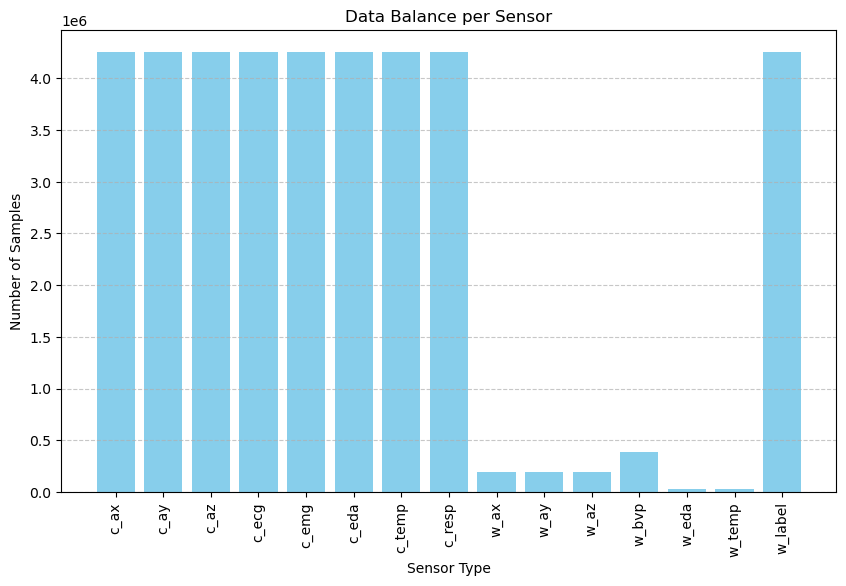

In [114]:
sensor_labels = [
    'c_ax', 'c_ay', 'c_az', 'c_ecg', 'c_emg', 
    'c_eda', 'c_temp', 'c_resp', 'w_ax', 'w_ay', 
    'w_az', 'w_bvp', 'w_eda', 'w_temp', 'w_label',
]

sensor_data_lengths = [
    len(c_ax), len(c_ay), len(c_az), len(c_ecg), len(c_emg), 
    len(c_eda), len(c_temp), len(c_resp), len(w_ax), len(w_ay), 
    len(w_az), len(w_bvp), len(w_eda), len(w_temp), len(w_label)
]

for label, length in zip(sensor_labels, sensor_data_lengths):
    print(f"{label}: {length}")

# Plotting
plt.figure(figsize=(10, 6))
plt.bar(sensor_labels, sensor_data_lengths, color='skyblue')
plt.title('Data Balance per Sensor')
plt.xlabel('Sensor Type')
plt.ylabel('Number of Samples')
plt.xticks(rotation=90)  # Rotate labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [ ]:
"""
It seems like the wrist sensor data has significantly fewer samples compared to the chest sensor data.

Options:

1. Exclude Wrist Data: 
        Make a dataset where the sensor data types are balanced (or close to balanced), 
        we can choose to exclude wrist data.

        This will give us a more uniform dataset for training, but we will be missing 
        some wrist specific data (like wrist_bvp, wrist_eda, and wrist_temp) which could
        provide useful insights.
        
2. Include Wrist Data:
        To include the wrist data, we need to handle the imbalance, we can:
        
            A) Upsample the wrist data: Duplicate or generate synthetic data 
               (using techniques like SMOTE) to balance the dataset.

            B) Downsample the chest data: Reduce the chest data to match the size of the 
               wrist data, though this might result in losing important information.
"""

Exclude Wrist Data

In [115]:
#numpy_data1=np.array([c_ax, c_ay, c_az,c_ecg,c_emg,c_eda,c_temp,c_resp,w_ax,w_ay,w_az,w_bvp,w_eda,w_temp])
numpy_data1=np.array([c_ax, c_ay, c_az,c_ecg,c_emg,c_eda,c_temp,c_resp,w_label])
numpy_data1=numpy_data1.T

#df = pd.DataFrame(data=numpy_data1, columns=["c_ax", "c_ay", "c_az","c_ecg","c_emg","c_eda","c_temp","c_resp","w_ax","w_ay","w_az","w_bvp","w_eda","w_temp"],orient='index') 
df = pd.DataFrame(data=numpy_data1, columns=["c_ax", "c_ay", "c_az","c_ecg","c_emg","c_eda","c_temp","c_resp","w_label"])
print("shape",df.shape)

shape (4255300, 9)


Box Plots Before Cleaning

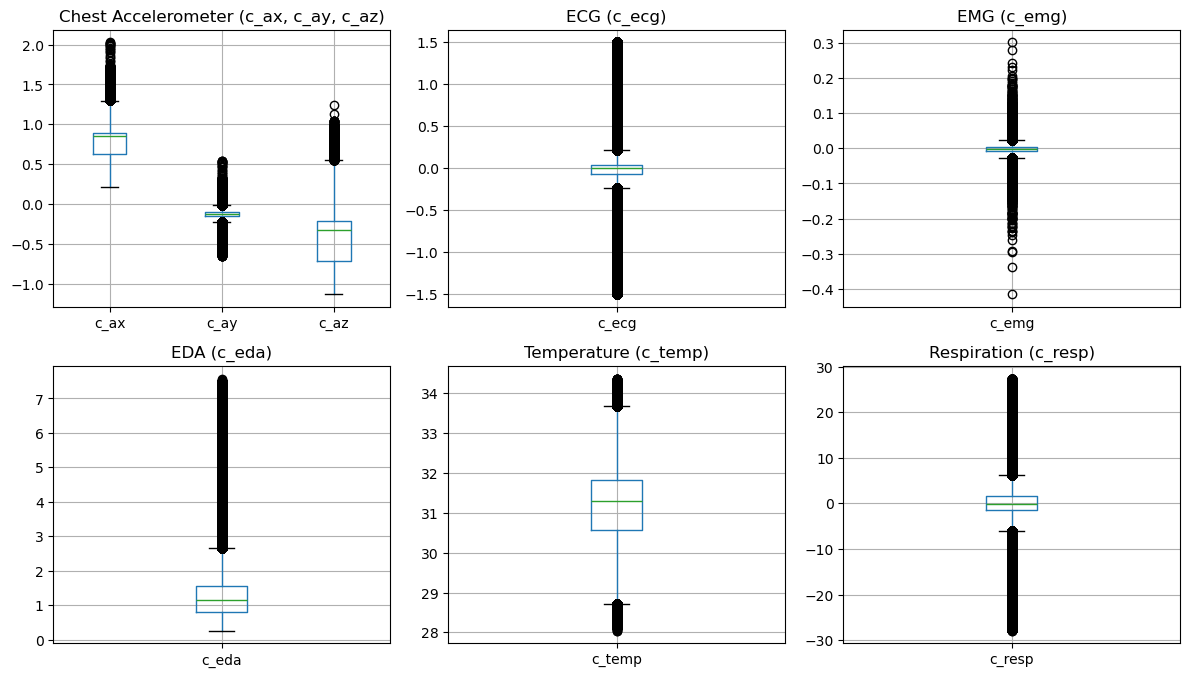

In [116]:
plt.figure(figsize=(12, 10))

# Boxplot for accelerometer data (chest)
plt.subplot(3, 3, 1)
df.boxplot(column=['c_ax', 'c_ay', 'c_az'])
plt.title('Chest Accelerometer (c_ax, c_ay, c_az)')

# Boxplot for ECG data
plt.subplot(3, 3, 2)
df.boxplot(column=['c_ecg'])
plt.title('ECG (c_ecg)')

# Boxplot for EMG data
plt.subplot(3, 3, 3)
df.boxplot(column=['c_emg'])
plt.title('EMG (c_emg)')

# Boxplot for EDA data
plt.subplot(3, 3, 4)
df.boxplot(column=['c_eda'])
plt.title('EDA (c_eda)')

# Boxplot for Temperature data
plt.subplot(3, 3, 5)
df.boxplot(column=['c_temp'])
plt.title('Temperature (c_temp)')

# Boxplot for Respiration data
plt.subplot(3, 3, 6)
df.boxplot(column=['c_resp'])
plt.title('Respiration (c_resp)')

plt.tight_layout()
plt.show()

Calculating IQR and Removing Outliers

In [117]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1
print("IQR is\n", IQR)

IQR is
 c_ax       0.271200
c_ay       0.054000
c_az       0.507400
c_ecg      0.112335
c_emg      0.012314
c_eda      0.746918
c_temp     1.240173
c_resp     3.100586
w_label    2.000000
dtype: float64


In [118]:
df_out = df[~((df < (Q1 - 1.5 * IQR)) |(df > (Q3 + 1.5 * IQR))).any(axis=1)]
print(df_out.shape)

(2100456, 9)


Box Plots After Cleaning

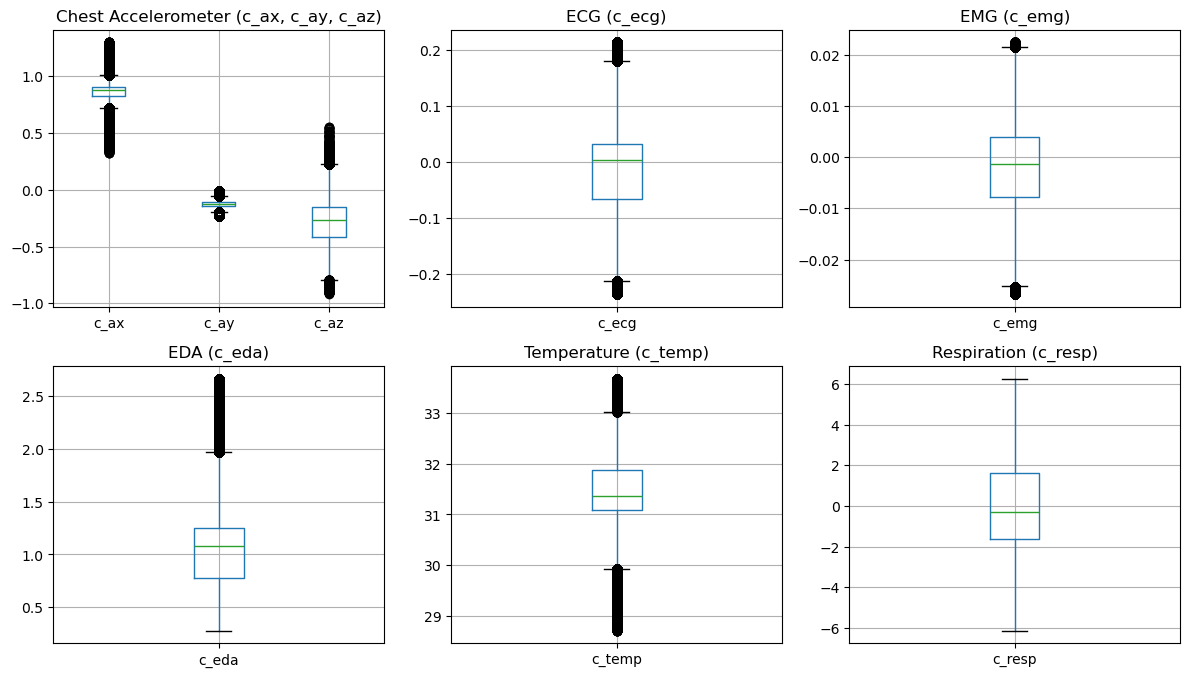

In [119]:
plt.figure(figsize=(12, 10))

# Boxplot for accelerometer data (chest)
plt.subplot(3, 3, 1)
df_out.boxplot(column=['c_ax', 'c_ay', 'c_az'])
plt.title('Chest Accelerometer (c_ax, c_ay, c_az)')

# Boxplot for ECG data
plt.subplot(3, 3, 2)
df_out.boxplot(column=['c_ecg'])
plt.title('ECG (c_ecg)')

# Boxplot for EMG data
plt.subplot(3, 3, 3)
df_out.boxplot(column=['c_emg'])
plt.title('EMG (c_emg)')

# Boxplot for EDA data
plt.subplot(3, 3, 4)
df_out.boxplot(column=['c_eda'])
plt.title('EDA (c_eda)')

# Boxplot for Temperature data
plt.subplot(3, 3, 5)
df_out.boxplot(column=['c_temp'])
plt.title('Temperature (c_temp)')

# Boxplot for Respiration data
plt.subplot(3, 3, 6)
df_out.boxplot(column=['c_resp'])
plt.title('Respiration (c_resp)')

plt.tight_layout()
plt.show()

In [120]:
(df_out.describe())

,c_ax,c_ay,c_az,c_ecg,c_emg,c_eda,c_temp,c_resp,w_label
count,2.100456e+06,2.100456e+06,2.100456e+06,2.100456e+06,2.100456e+06,2.100456e+06,2.100456e+06,2.100456e+06,2.100456e+06
mean,8.317685e-01,-1.233951e-01,-3.003224e-01,-1.787775e-02,-1.975948e-03,1.091733e+00,3.144793e+01,-2.909448e-02,1.164535e+00
std,1.124673e-01,2.816034e-02,2.486282e-01,8.312552e-02,8.932746e-03,4.379497e-01,5.746423e-01,2.247824e+00,1.510026e+00
min,3.218000e-01,-2.308000e-01,-9.208000e-01,-2.364807e-01,-2.677917e-02,2.784729e-01,2.871490e+01,-6.132507e+00,0.000000e+00
25%,8.298000e-01,-1.418000e-01,-4.118000e-01,-6.573486e-02,-7.736206e-03,7.759094e-01,3.109299e+01,-1.637268e+00,0.000000e+00
50%,8.786000e-01,-1.258000e-01,-2.696000e-01,2.655029e-03,-1.419067e-03,1.082993e+00,3.136053e+01,-2.746582e-01,0.000000e+00
75%,9.018000e-01,-1.078000e-01,-1.558000e-01,3.240967e-02,3.936768e-03,1.254272e+00,3.186548e+01,1.618958e+00,2.000000e+00
max,1.298600e+00,-1.480001e-02,5.502000e-01,2.128601e-01,2.243042e-02,2.666855e+00,3.367465e+01,6.269836e+00,4.000000e+00


In [121]:
(df_out.head())

,c_ax,c_ay,c_az,c_ecg,c_emg,c_eda,c_temp,c_resp,w_label
393691,0.6430,-0.0600,-0.6966,-0.044998,-0.008011,2.652359,28.717804,-0.965881,1.0
394476,0.6408,-0.0638,-0.6892,-0.176926,-0.014557,2.648163,28.716339,1.914978,1.0
395154,0.6394,-0.0602,-0.6918,0.052231,0.009659,2.662659,28.719208,-1.673889,1.0
396635,0.6354,-0.0684,-0.6998,-0.138611,0.000000,2.662277,28.716339,2.491760,1.0
402178,0.6392,-0.0626,-0.6972,0.045822,-0.006775,2.648163,28.820953,2.105713,1.0


Histogram

array([[<Axes: title={'center': 'c_ax'}>,
        <Axes: title={'center': 'c_ay'}>,
        <Axes: title={'center': 'c_az'}>],
       [<Axes: title={'center': 'c_ecg'}>,
        <Axes: title={'center': 'c_emg'}>,
        <Axes: title={'center': 'c_eda'}>],
       [<Axes: title={'center': 'c_temp'}>,
        <Axes: title={'center': 'c_resp'}>,
        <Axes: title={'center': 'w_label'}>]], dtype=object)

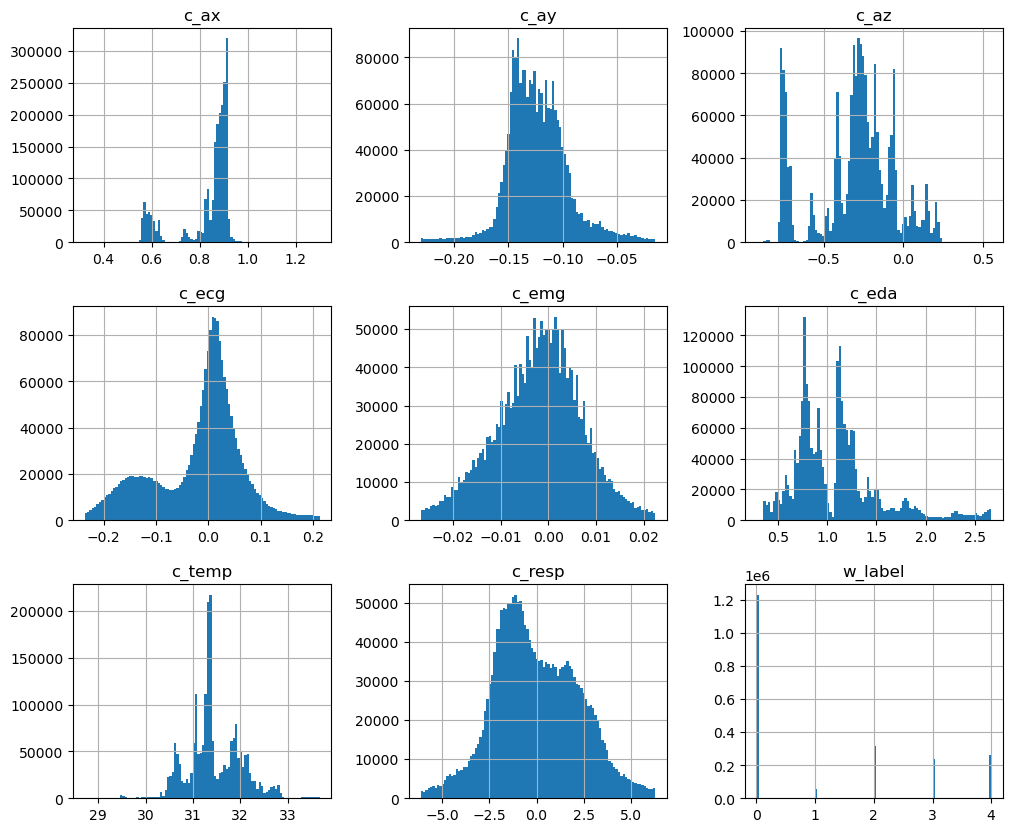

In [122]:
# Distribution of a set of data
df_out.hist(bins=100, figsize = (12,10))

Correlation Matrix

In [123]:
"""
The correlation matrix is a square matrix where each entry in the matrix represents 
the correlation coefficient between two variables (columns) in the DataFrame.

Correlation values range from:

    +1: Perfect positive correlation (when one variable increases, the other also increases).
    -1: Perfect negative correlation (when one variable increases, the other decreases).
     0: No correlation (the variables are not linearly related).
"""

corr_matrix=df_out.corr()
(corr_matrix)

,c_ax,c_ay,c_az,c_ecg,c_emg,c_eda,c_temp,c_resp,w_label
c_ax,1.000000,-0.023870,0.890463,-0.009258,-0.001814,0.086628,0.121247,-0.018757,-0.509452
c_ay,-0.023870,1.000000,0.027892,0.004532,-0.001511,-0.023619,-0.063603,-0.016261,-0.228733
c_az,0.890463,0.027892,1.000000,-0.004805,-0.002277,-0.138557,0.236908,0.001604,-0.410491
c_ecg,-0.009258,0.004532,-0.004805,1.000000,-0.005601,-0.022128,0.014425,0.064024,0.003692
c_emg,-0.001814,-0.001511,-0.002277,-0.005601,1.000000,-0.005357,-0.003173,-0.000339,-0.006690
c_eda,0.086628,-0.023619,-0.138557,-0.022128,-0.005357,1.000000,-0.541162,-0.030029,-0.119094
c_temp,0.121247,-0.063603,0.236908,0.014425,-0.003173,-0.541162,1.000000,0.019251,0.172247
c_resp,-0.018757,-0.016261,0.001604,0.064024,-0.000339,-0.030029,0.019251,1.000000,-0.003661
w_label,-0.509452,-0.228733,-0.410491,0.003692,-0.006690,-0.119094,0.172247,-0.003661,1.000000


Creating four subsets of data based on the label

In [124]:
base_df = df_out.loc[(df_out['w_label'] == 0)]
stress_df = df_out.loc[(df_out['w_label'] == 1)]
amus_df = df_out.loc[(df_out['w_label'] == 2)]
medi_df = df_out.loc[(df_out['w_label'] == 3)]

Plotting Sensor Data for Different Conditions

In [125]:
y_ax=base_df["c_ax"][:20000].values
y_ax_s=stress_df["c_ax"][:20000].values
y_ax_a=amus_df["c_ax"][:20000].values
y_ax_m=medi_df["c_ax"][:20000].values
x_ax=np.arange(len(y_ax))

y_ay=base_df["c_ay"][:20000].values
y_ay_s=stress_df["c_ay"][:20000].values
y_ay_a=amus_df["c_ay"][:20000].values
y_ay_m=medi_df["c_ay"][:20000].values
x_ay=np.arange(len(y_ay))

y_az=base_df["c_az"][:20000].values
y_az_s=stress_df["c_az"][:20000].values
y_az_a=amus_df["c_az"][:20000].values
y_az_m=medi_df["c_az"][:20000].values
x_az=np.arange(len(y_az))

y_ecg=base_df["c_ecg"][:1000].values
y_ecg_s=stress_df["c_ecg"][:1000].values
y_ecg_a=amus_df["c_ecg"][:1000].values
y_ecg_m=medi_df["c_ecg"][:1000].values
x_ecg=np.arange(len(y_ecg))

y_emg=base_df["c_emg"][:50].values
y_emg_s=stress_df["c_emg"][:50].values
y_emg_a=amus_df["c_emg"][:50].values
y_emg_m=medi_df["c_emg"][:50].values
x_emg=np.arange(len(y_emg))

y_eda=base_df["c_eda"][:20000].values
y_eda_s=stress_df["c_eda"][:20000].values
y_eda_a=amus_df["c_eda"][:20000].values
y_eda_m=medi_df["c_eda"][:20000].values
x_eda=np.arange(len(y_eda))

y_temp=base_df["c_temp"][:20000].values
y_temp_s=stress_df["c_temp"][:20000].values
y_temp_a=amus_df["c_temp"][:20000].values
y_temp_m=medi_df["c_temp"][:20000].values
x_temp=np.arange(len(y_temp))

y_resp=base_df["c_resp"][:10000].values
y_resp_s=stress_df["c_resp"][:10000].values
y_resp_a=amus_df["c_resp"][:10000].values
y_resp_m=medi_df["c_resp"][:10000].values
x_resp=np.arange(len(y_resp))

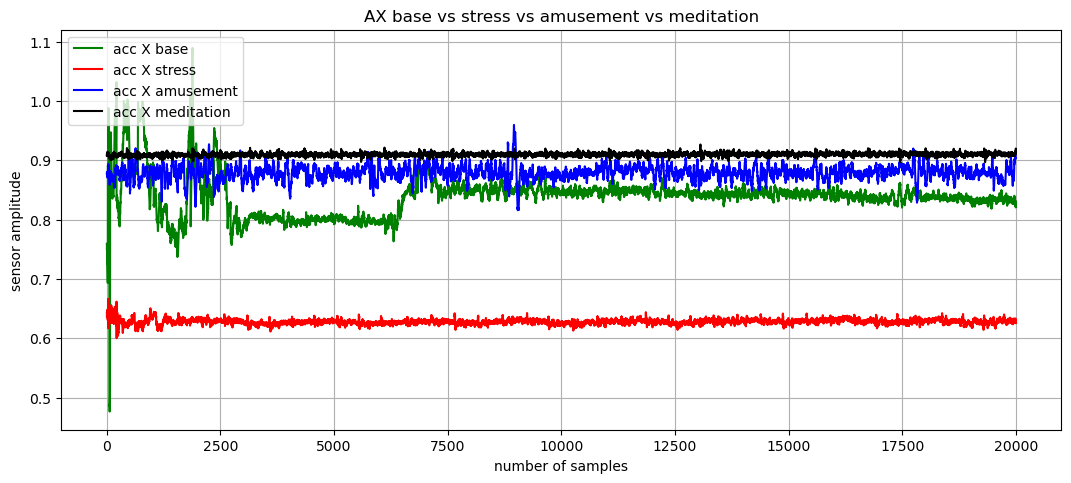

In [126]:

fig= plt.figure(figsize=(5,2))
ax1= fig.add_axes([0.1,0.1,2,2])
ax1.plot(x_ax,y_ax,color='green',label="acc X base")
ax1.plot(x_ax,y_ax_s,color='red',label="acc X stress")
ax1.plot(x_ax,y_ax_a,color='blue',label="acc X amusement")
ax1.plot(x_ax,y_ax_m,color='black',label="acc X meditation")
ax1.set(xlabel='number of samples', ylabel = 'sensor amplitude', title = 'AX base vs stress vs amusement vs meditation')
ax1.grid()
plt.legend(loc='upper left')
plt.show()

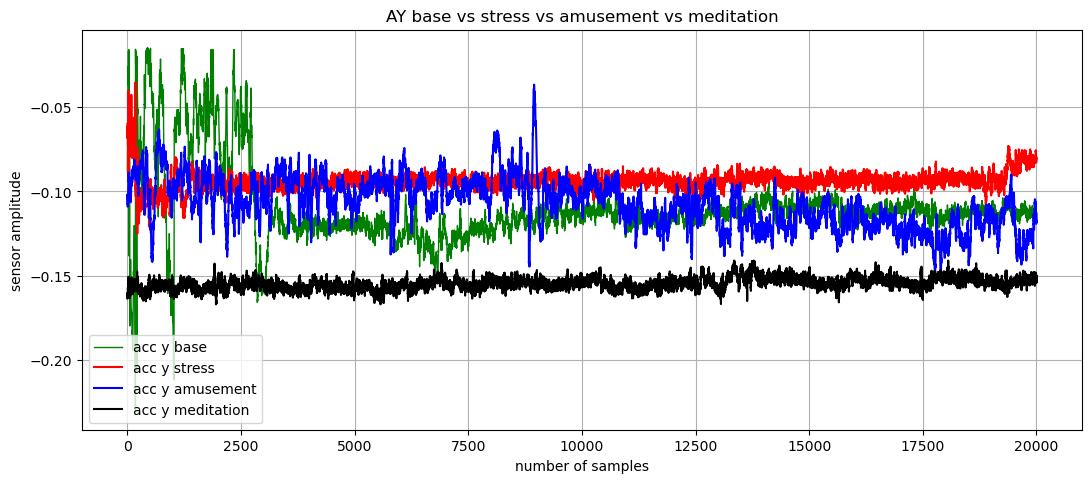

In [127]:

fig= plt.figure(figsize=(5,2))
ax1= fig.add_axes([0.1,0.1,2,2])
ax1.plot(x_ax,y_ay,color='green',label="acc y base",linewidth = 1)
ax1.plot(x_ax,y_ay_s,color='red',label="acc y stress")
ax1.plot(x_ax,y_ay_a,color='blue',label="acc y amusement")
ax1.plot(x_ax,y_ay_m,color='black',label="acc y meditation")
ax1.set(xlabel='number of samples', ylabel = 'sensor amplitude', title = 'AY base vs stress vs amusement vs meditation')
ax1.grid()
plt.legend(loc='lower left')
plt.show()

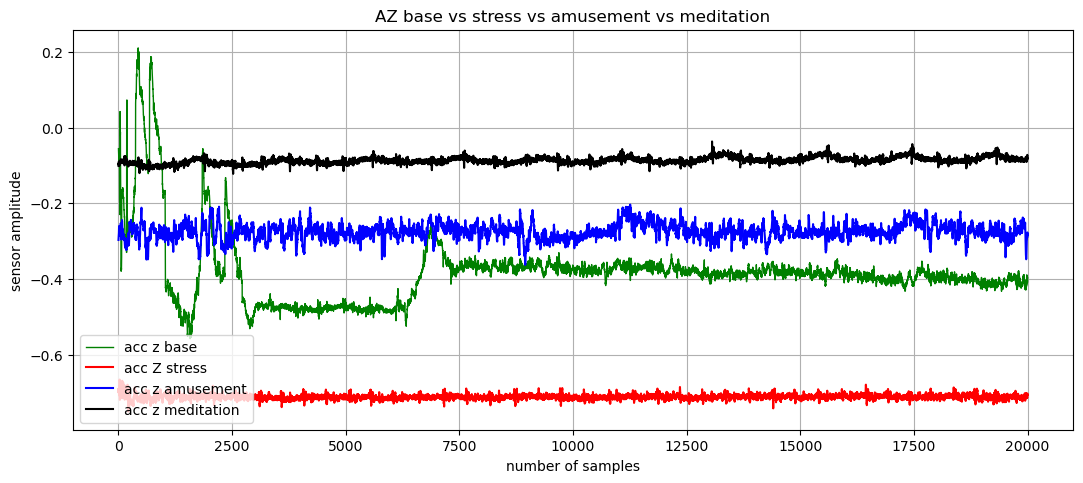

In [128]:

fig= plt.figure(figsize=(5,2))
ax1= fig.add_axes([0.1,0.1,2,2])
ax1.plot(x_ax,y_az,color='green',label="acc z base",linewidth = 1)
ax1.plot(x_ax,y_az_s,color='red',label="acc Z stress")
ax1.plot(x_ax,y_az_a,color='blue',label="acc z amusement")
ax1.plot(x_ax,y_az_m,color='black',label="acc z meditation")
ax1.set(xlabel='number of samples', ylabel = 'sensor amplitude', title = 'AZ base vs stress vs amusement vs meditation')
ax1.grid()
plt.legend(loc='lower left')
plt.show()


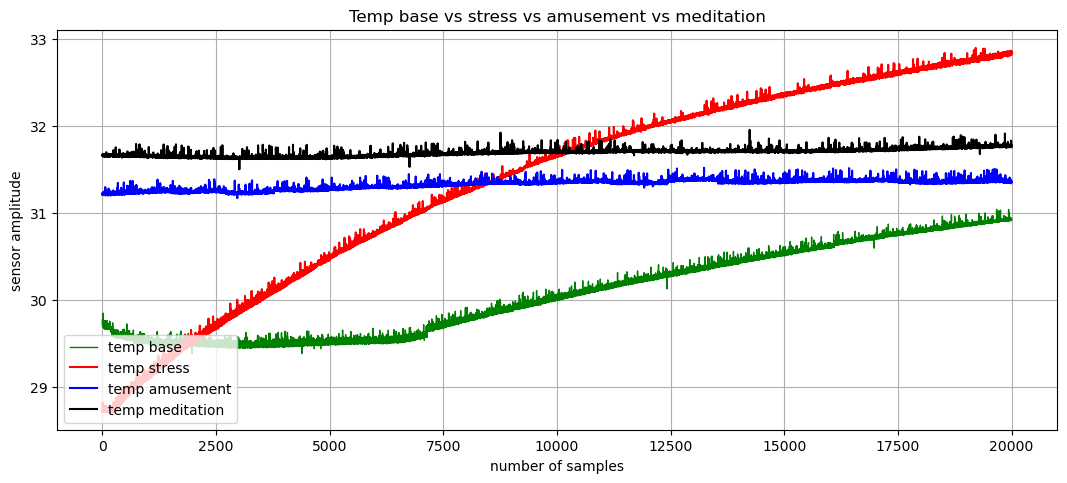

In [129]:

fig= plt.figure(figsize=(5,2))
ax1= fig.add_axes([0.1,0.1,2,2])
ax1.plot(x_temp,y_temp,color='green',label="temp base",linewidth = 1)
ax1.plot(x_temp,y_temp_s,color='red',label="temp stress")
ax1.plot(x_temp,y_temp_a,color='blue',label="temp amusement")
ax1.plot(x_temp,y_temp_m,color='black',label="temp meditation")
ax1.set(xlabel='number of samples', ylabel = 'sensor amplitude', title = 'Temp base vs stress vs amusement vs meditation')
ax1.grid()
plt.legend(loc='lower left')
plt.show()


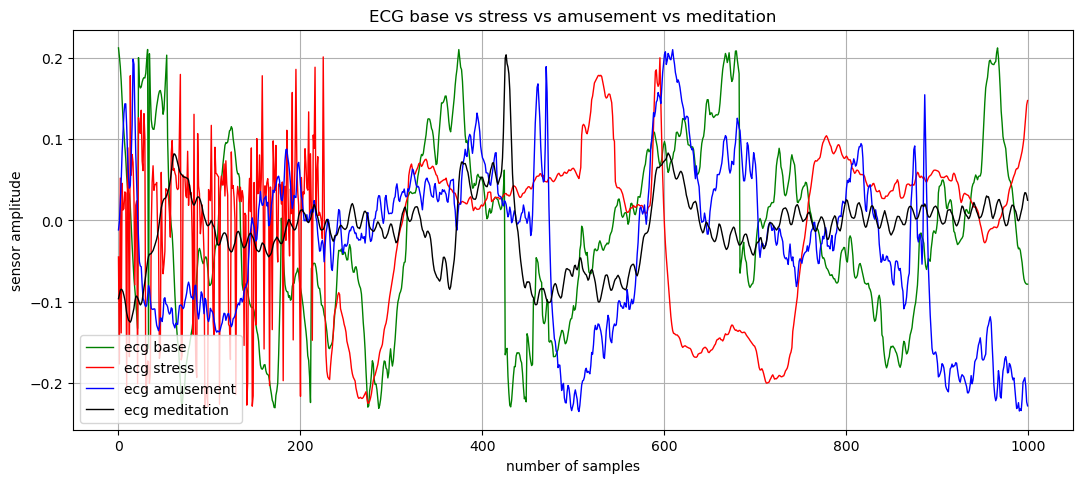

In [130]:

fig= plt.figure(figsize=(5,2))
ax1= fig.add_axes([0.1,0.1,2,2])
ax1.plot(x_ecg,y_ecg,color='green',label="ecg base",linewidth = 1)
ax1.plot(x_ecg,y_ecg_s,color='red',label="ecg stress",linewidth = 1)
ax1.plot(x_ecg,y_ecg_a,color='blue',label="ecg amusement",linewidth = 1)
ax1.plot(x_ecg,y_ecg_m,color='black',label="ecg meditation",linewidth = 1)
ax1.set(xlabel='number of samples', ylabel = 'sensor amplitude', title = 'ECG base vs stress vs amusement vs meditation')
ax1.grid()
plt.legend(loc='lower left')
plt.show()


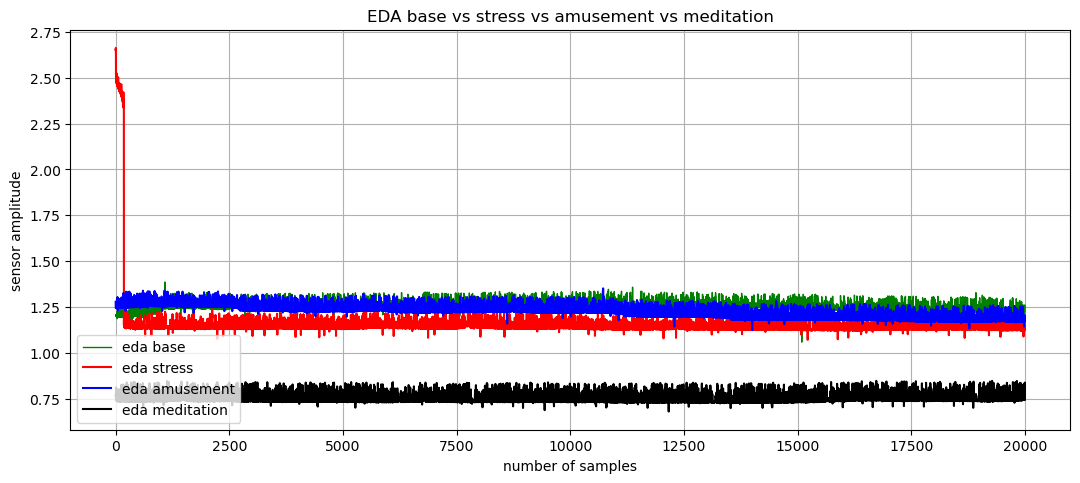

In [131]:

fig= plt.figure(figsize=(5,2))
ax1= fig.add_axes([0.1,0.1,2,2])
ax1.plot(x_eda,y_eda,color='green',label="eda base",linewidth = 1)
ax1.plot(x_eda,y_eda_s,color='red',label="eda stress")
ax1.plot(x_eda,y_eda_a,color='blue',label="eda amusement")
ax1.plot(x_eda,y_eda_m,color='black',label="eda meditation")
ax1.set(xlabel='number of samples', ylabel = 'sensor amplitude', title = 'EDA base vs stress vs amusement vs meditation')
ax1.grid()
plt.legend(loc='lower left')
plt.show()


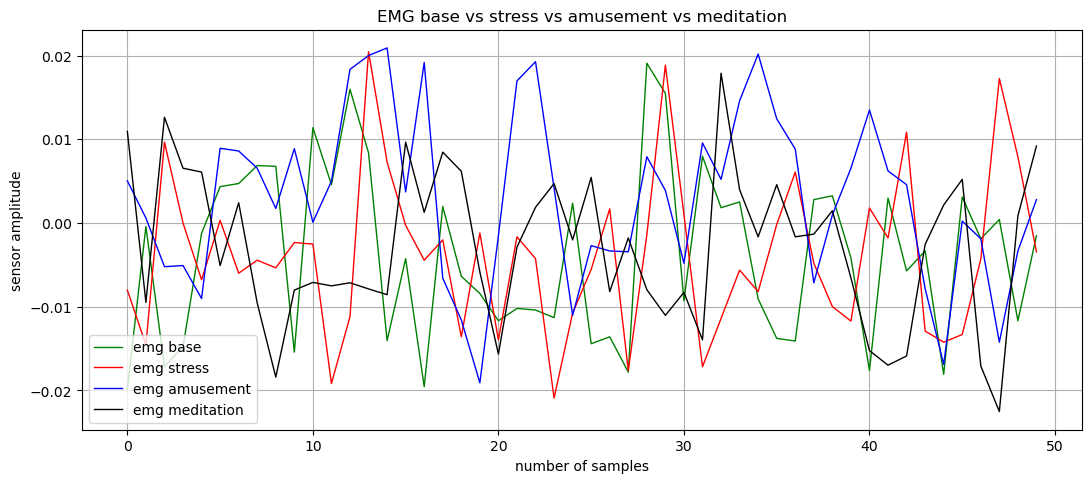

In [132]:

fig= plt.figure(figsize=(5,2))
ax1= fig.add_axes([0.1,0.1,2,2])
ax1.plot(x_emg,y_emg,color='green',label="emg base",linewidth = 1)
ax1.plot(x_emg,y_emg_s,color='red',label="emg stress",linewidth = 1)
ax1.plot(x_emg,y_emg_a,color='blue',label="emg amusement",linewidth = 1)
ax1.plot(x_emg,y_emg_m,color='black',label="emg meditation",linewidth = 1)
ax1.set(xlabel='number of samples', ylabel = 'sensor amplitude', title = 'EMG base vs stress vs amusement vs meditation')
ax1.grid()
plt.legend(loc='lower left')
plt.show()


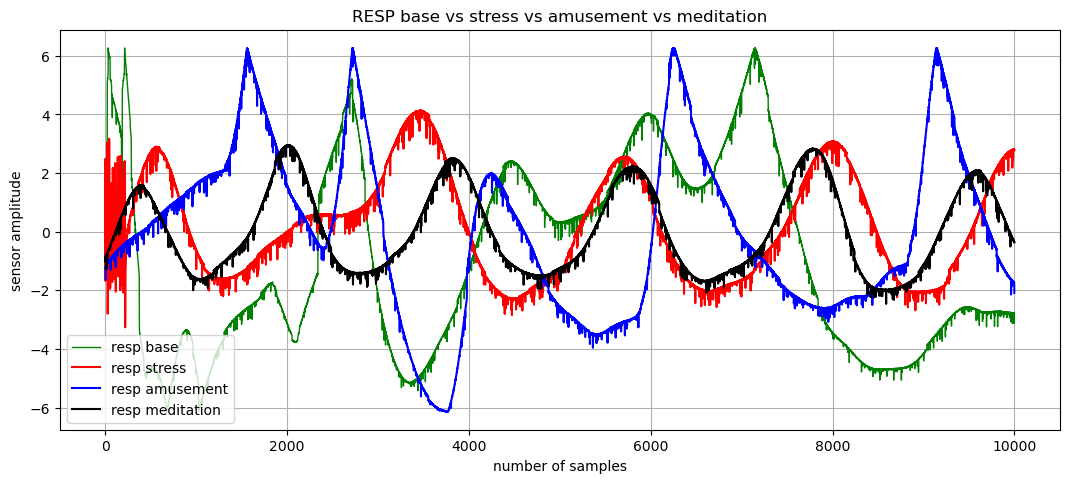

In [133]:

fig= plt.figure(figsize=(5,2))
ax1= fig.add_axes([0.1,0.1,2,2])
ax1.plot(x_resp,y_resp,color='green',label="resp base",linewidth = 1)
ax1.plot(x_resp,y_resp_s,color='red',label="resp stress")
ax1.plot(x_resp,y_resp_a,color='blue',label="resp amusement")
ax1.plot(x_resp,y_resp_m,color='black',label="resp meditation")
ax1.set(xlabel='number of samples', ylabel = 'sensor amplitude', title = 'RESP base vs stress vs amusement vs meditation')
ax1.grid()
plt.legend(loc='lower left')
plt.show()